# Initial Setup

This notebook contains the initial setup of the environment and download of required datasets for training, evaluation, and visualization.

Before we can start, we need to install the required dependencies for this project. This project depends on the following libraries:

- **pandas** & **numpy**: Tabular data manipulation and numerical operations.
- **scipy**: Fundamental algorithms for scientific computing in Python.
- **pillow**: Library for loading and manipulating images.
- **opencv-python** & **opencv-contrib-python**: Computer vision library for image processing.
- **torch** & **torchvision**: A library for deep learning in Python.
- **ultralytics**: Library for use of YOLO models.
- **matplotlib**, **seaborn** & **pyvista** : Plotting libraries for data visualization.
- **jupyter** & **ipywidgets**: For displaying widgets in the notebook.
- **gdown**: Tool for downloading data from Google Drive.

In [9]:
%%capture
%pip install numpy pandas scipy pillow opencv-python opencv-contrib-python torch torchvision
%pip install ultralytics matplotlib seaborn pyvista[jupyter] jupyter ipywidgets gdown einops
%pip install git+https://github.com/microsoft/MoGe.git

In [1]:
import os
import sys

import matplotlib.pyplot as plt

In [2]:
# Add the `code` directory to the path.
sys.path.append("../")

import util
import dataset

In [10]:
# This code is just here so I can reload the external files in case I make
# changes to them after having already imported them.
import importlib

importlib.reload(util)
importlib.reload(dataset);

We can then download the dataset from the official CMU Panoptic Dataset website. It is available at [here](http://domedb.perception.cs.cmu.edu/). Note that there is also an official download script, but this project uses some custom class to download all the relevant data.

The code to actually download the dataset can be found in the `dataset.py` python module.

In [ ]:
data = dataset.CmuPanopticDataset(path="../data/panoptic")

# Warning: Running this will take a long time and take up a lot of disk space.
data.download(num_hd_cams=16)

# Uncomment and run the following to only download the files used for evaluation
# of the complete system (a subset of 11 sequences not used during training).
# data.download(num_vga_cams=16, scenes=dataset.CmuPanopticDataset.test_scenes)

Now that we have the raw dataset, we can preprocess it into a format useful for training the custom YOLO based model as well as for learning the Kalman parameters. This is also implemented on the `CmuPanopticDataset` class in `dataset.py`. The YOLO dataset is generated by talking frames every second of the video from a random camera out of the 16 that we loaded. Only if at least one person annotation exists will a sample be created.

In [ ]:
# The generation of the YOLO dataset is randomized. Therefore we set the seed to
# get a reproducible dataset.
util.set_seed(42)

# Warning: Again, running this will take quite a long time. Therefore the below
# code will only execute if the folder does not yet exist. Delete the folder to
# recreate the 
if not os.path.exists("../data/yolo"):
    data.extract_yolo_dataset(path="../data/yolo")
if not os.path.exists("../data/kalman"):
    data.extract_kalman_dataset(path="../data/kalman")

Finally, let's make use we successfully downloaded and extracted the dataset by loading some samples from it. First, let us load an image from the YOLO dataset.

Number of training samples: 11122
Number of validation samples: 3098


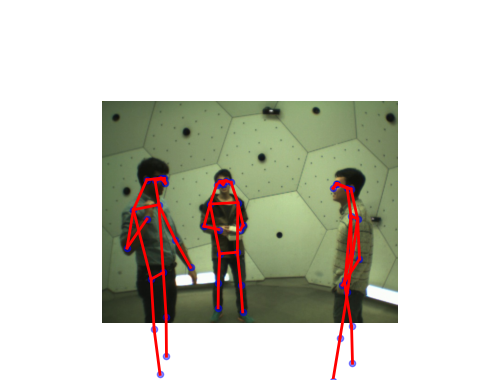

In [12]:
data = dataset.YoloDataset("../data/yolo/train")
data_val = dataset.YoloDataset("../data/yolo/val")

print("Number of training samples:", len(data))
print("Number of validation samples:", len(data_val))

img, ann = data[1]
for kp in ann:
    for i, j in util.SKELETON:
        plt.plot([kp[i, 0], kp[j, 0]], [kp[i, 1], kp[j, 1]], color='red', linewidth=2)
    for k in range(17):
        plt.scatter(kp[k, 0], kp[k, 1], s=20, color='#0000ff70')
plt.imshow(img.permute(1, 2, 0))
plt.xlim(-200, 800)
plt.ylim(600, -200)
plt.axis("off")
plt.show()

Then let us load also a track from the dataset intended to train the Kalman filter.

In [ ]:
# TODO